In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("Movie_classification.csv")

In [13]:
df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


Data preprocessing, Cleaning & Defining variables

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

In [15]:
#Time taken has null entries
print(df['Time_taken'].mean())

157.3914979757085


In [16]:
df ['Time_taken']= df['Time_taken'].fillna(157.3914979757085)

In [17]:
df = pd.get_dummies(df, columns = ['3D_available', 'Genre'], drop_first = True)

In [18]:
df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,...,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,...,109.60,223.840,23,494,48000,1,True,False,False,True
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,...,146.64,243.456,42,462,43200,0,False,False,True,False
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,...,147.88,2022.400,38,458,69400,1,False,True,False,False
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,...,185.36,225.344,45,472,66800,1,True,False,True,False
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,...,176.48,225.792,55,395,72400,1,False,False,True,False


In [19]:
#Models tend to give lot of errors when using True/False so we convert to integers
df[['3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']]= df[['3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']].replace({True:1, False:0})

C:\Users\tebog\AppData\Local\Temp\ipykernel_13760\579756961.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']]= df[['3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']].replace({True:1, False:0})


In [20]:
df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,...,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,...,109.60,223.840,23,494,48000,1,1,0,0,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,...,146.64,243.456,42,462,43200,0,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,...,147.88,2022.400,38,458,69400,1,0,1,0,0
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,...,185.36,225.344,45,472,66800,1,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,...,176.48,225.792,55,395,72400,1,0,0,1,0


In [21]:
x = df.drop('Start_Tech_Oscar', axis=1)

In [22]:
for a in x.columns:
    if 'Start_Tech_Oscar' in a:
        print('Yes')
    else:
        print('No')

No
No
No
No
No
No
No
No
No
No
No
No
No
No
No
No
No
No
No
No


In [23]:
x.shape

(506, 20)

In [24]:
y = df['Start_Tech_Oscar']

In [25]:
y.shape

(506,)

Test train split

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state= 0)

In [28]:
x_train.shape

(404, 20)

Classification tree training

In [29]:
from sklearn import tree

In [30]:
clftree = tree.DecisionTreeClassifier(max_depth=3)

In [31]:
clftree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

Prediction using trained model

In [32]:
y_train_predicted= clftree.predict(x_train)
y_test_predicted= clftree.predict(x_test)

Checking the Model perfomance

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [34]:
confusion_matrix(y_train, y_train_predicted)

array([[172,  14],
       [126,  92]])

In [35]:
confusion_matrix(y_test, y_test_predicted)

array([[39,  5],
       [41, 17]])

In [36]:
accuracy_score(y_test, y_test_predicted)

0.5490196078431373

Plotting the decision tree

In [37]:
dot_data = tree.export_graphviz(clftree, feature_names= x_train.columns, filled = True)

In [38]:
from IPython.display import Image

In [39]:
import pydotplus

In [40]:
graph = pydotplus.graph_from_dot_data(dot_data)

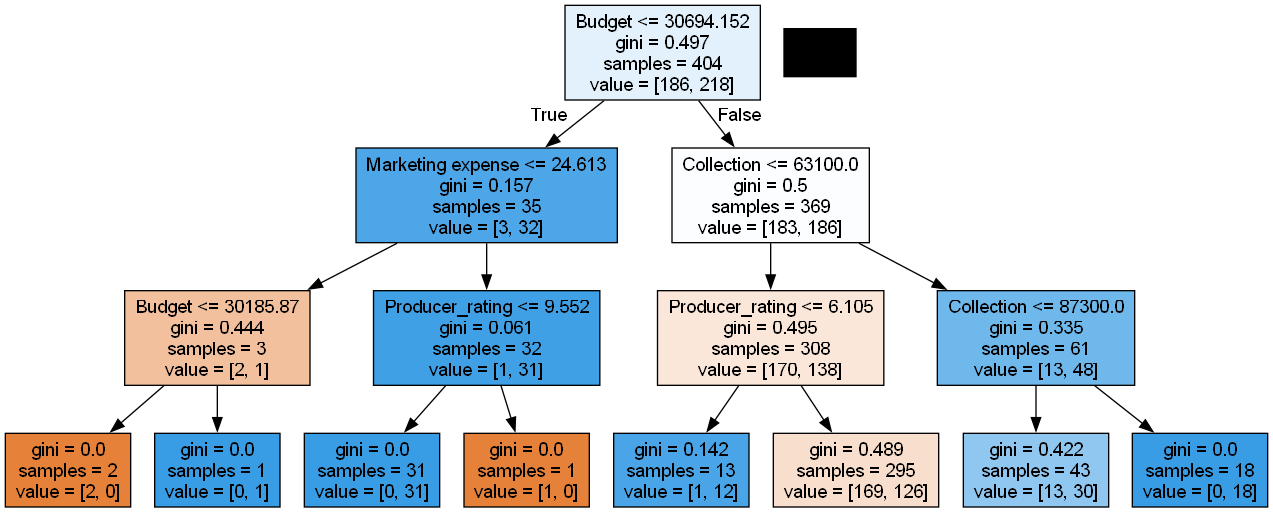

In [41]:
Image(graph.create_png())

-Blue represents the domination of 1s, which is the movie winning an oscar.
-Orange represents zeros, which is the movie not winning an oscar.
-White showing no dominance.

In [42]:
#Making use of parameters to increase accuracy
clftree2 = tree.DecisionTreeClassifier(min_samples_leaf=20, max_depth=4)
clftree2.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=20)

In [43]:
dot_data2 = tree.export_graphviz(clftree2, feature_names= x_train.columns, filled = True)

In [44]:
graph2 = pydotplus.graph_from_dot_data(dot_data2)

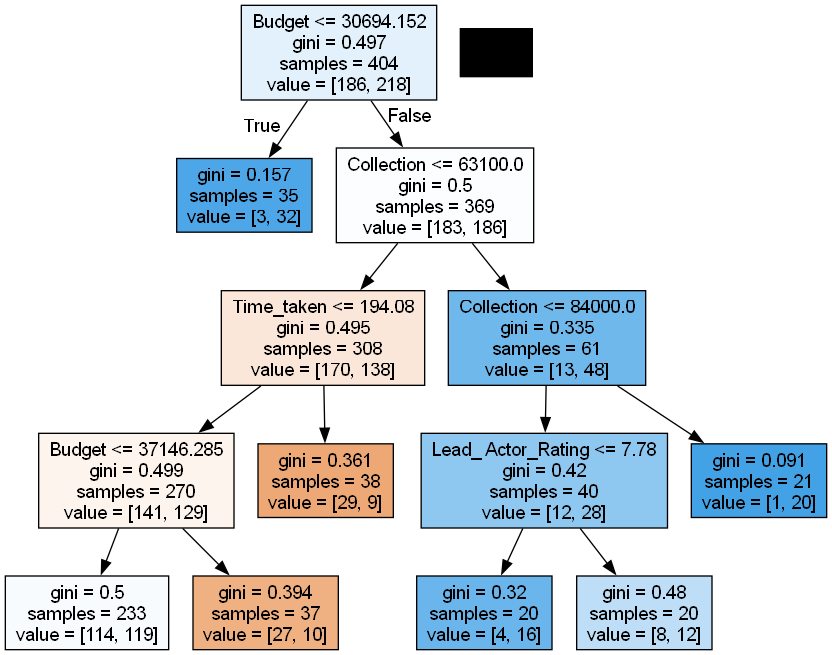

In [45]:
Image(graph2.create_png())

In [46]:
accuracy_score(y_test, clftree2.predict(x_test))

0.5588235294117647

Bagging

In [47]:
clftree = tree.DecisionTreeClassifier()

In [48]:
from sklearn.ensemble import BaggingClassifier

In [49]:
bag_clf = BaggingClassifier(estimator= clftree, n_estimators= 1000,bootstrap=True, n_jobs=-1, random_state=0)

In [50]:
bag_clf.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=1000,
                  n_jobs=-1, random_state=0)

In [51]:
y_test_predicted2= bag_clf.predict(x_test)

In [52]:
confusion_matrix(y_test, y_test_predicted2)

array([[28, 16],
       [21, 37]])

In [53]:
accuracy_score(y_test, y_test_predicted2)

0.6372549019607843

Finally with bagging, the accuracy score improved to 63%. Thats good

Random Forest on the same...

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf_clf = RandomForestClassifier(n_estimators=1000,n_jobs=1, random_state=42 )

In [56]:
rf_clf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=1000, n_jobs=1, random_state=42)

In [57]:
y_test_predicted3 = rf_clf.predict(x_test)

In [58]:
confusion_matrix(y_test, y_test_predicted3)

array([[25, 19],
       [18, 40]])

In [59]:
accuracy_score(y_test, y_test_predicted3)

0.6372549019607843

I can play around with parameters found within classifying object of the model, such as n_estimators, to increase the accuracy score, but that will be time consuming so we use

Grid Search:

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
grid= {'max_features':[4,5,6,7,8,9,10],
      'min_samples_split':[2,3,10],
      'n_estimators':[250,500,100]}
#Dictionary of all parameters and different arguments we want to try

In [62]:
grid_search = GridSearchCV(rf_clf, grid,n_jobs=-1, cv=5, scoring='accuracy')

In [63]:
grid_search.fit(x_train, y_train)
#Took 4 minitues to fit yesses

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=1000, n_jobs=1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_features': [4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 10],
                         'n_estimators': [250, 500, 100]},
             scoring='accuracy')

In [64]:
grid_search.best_params_

{'max_features': 6, 'min_samples_split': 3, 'n_estimators': 250}

In [65]:
#Creating the best model
best_model=grid_search.best_estimator_

In [66]:
best_model.predict(x_test)

array([0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0])

In [67]:
accuracy_score(y_test, best_model.predict(x_test))

0.6274509803921569

Gradient boosting

In [68]:
from sklearn.ensemble import GradientBoostingClassifier

In [69]:
gbc_clf = GradientBoostingClassifier()

In [70]:
gbc_clf.fit(x_train, y_train)

GradientBoostingClassifier()

In [71]:
gbc_clf.predict(x_test)

array([1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0])

In [72]:
accuracy_score(y_test, gbc_clf.predict(x_test))

0.5784313725490197

Let me try to increase the accuracy score by laying around with the hyperparaemter

In [73]:
gbc_clf2 = GradientBoostingClassifier(learning_rate= 0.02, n_estimators=1000, max_depth=1, random_state=42)

In [74]:
gbc_clf2.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.02, max_depth=1, n_estimators=1000,
                           random_state=42)

In [75]:
accuracy_score(y_test, gbc_clf2.predict(x_test))

0.6176470588235294

It increased nicely, but lets try grid search and see if it wont get any better

In [76]:
prameters={'learning_rate':[0.01, 0.05,0.1],
          'n_estimators':[500, 750, 1000],
          'max_depth':[1, 2, 3, 4, 5]}

In [77]:
new_grid_search=GridSearchCV(gbc_clf2,prameters , n_jobs=-1, cv=5, scoring='accuracy')

In [78]:
new_grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=GradientBoostingClassifier(learning_rate=0.02,
                                                  max_depth=1,
                                                  n_estimators=1000,
                                                  random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [1, 2, 3, 4, 5],
                         'n_estimators': [500, 750, 1000]},
             scoring='accuracy')

In [79]:
new_grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 1000}

In [80]:
new_model = new_grid_search.best_estimator_

In [81]:
accuracy_score(y_test, new_model.predict(x_test))

0.5490196078431373

Ada boost

In [82]:
from sklearn.ensemble import AdaBoostClassifier

In [83]:
ada_clf = AdaBoostClassifier(learning_rate=0.02, n_estimators=5000, random_state=42)

In [84]:
ada_clf.fit(x_train, y_train)

AdaBoostClassifier(learning_rate=0.02, n_estimators=5000, random_state=42)

In [85]:
accuracy_score(y_test, ada_clf.predict(x_test))

0.5490196078431373

In [86]:
ada_clf2= AdaBoostClassifier(rf_clf, learning_rate=0.05, n_estimators=500)

In [87]:
ada_clf2.fit(x_train, y_train)

AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=1000, n_jobs=1,
                                                    random_state=42),
                   learning_rate=0.05, n_estimators=500)

In [88]:
accuracy_score(y_test, ada_clf2.predict(x_test))

0.6274509803921569

After using the random forest classifier as an estimator in the AdaBoostClassifier the accuracy increases greatly

XG Boost

In [89]:
import xgboost as xgb

In [90]:
xgb_clf = xgb.XGBClassifier(n_estimators=1000, max_depth=5, learning_rate=0.3)

In [91]:
xgb_clf.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [92]:
accuracy_score(y_test, xgb_clf.predict(x_test))

0.6568627450980392

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

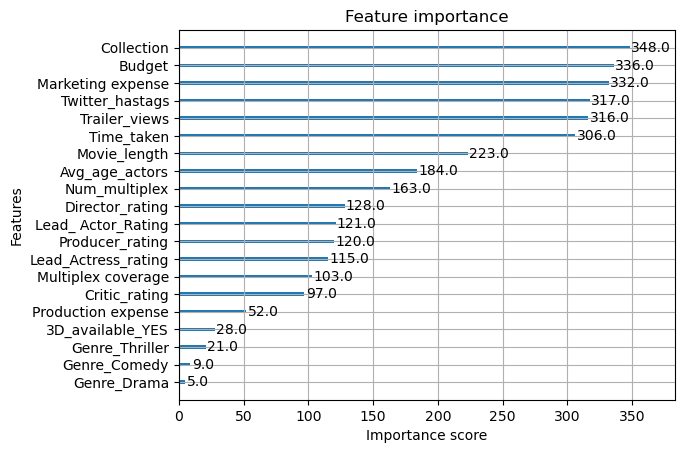

In [93]:
#Below graph will show importance of variables
xgb.plot_importance(xgb_clf)

Accuracy increased by a great percentage. Lets try to see if it wont go beyond with gridsearch

In [94]:
xgb_clf = xgb.XGBClassifier(n_estimators=250, learning_rate=0.3,random_state=42)

In [95]:
params= {'max_depth':[3,5,7,9,10],
        'gamma':[0.1, 0.2, 0.3],
        'subsample':[0.8, 0.9],
        'colsample_bytree':[0.8, 0.9],
        'reg_alpha':[0.01, 0.1, 1]
        }

In [96]:
grid_search_xgb=GridSearchCV(xgb_clf,params,scoring='accuracy',n_jobs=-1,cv=5)

In [97]:
grid_search_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=250,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9],
                         'gamma': [0.1, 0.2, 0.3],
                         'max_depth': [3, 5, 7, 9, 10],
                         'reg_alpha': [0.01, 0.1, 1], 'subsample': [0.8, 0.9]},
             scoring='accuracy')

In [98]:
grid_search_xgb.best_params_

{'colsample_bytree': 0.8,
 'gamma': 0.2,
 'max_depth': 5,
 'reg_alpha': 0.1,
 'subsample': 0.8}

In [99]:
best_xgb=grid_search_xgb.best_estimator_

In [100]:
accuracy_score(y_test, best_xgb.predict(x_test))

0.6568627450980392